# Clustering

In [1]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import rand_score, jaccard_score

from scipy.cluster.hierarchy import dendrogram

from umap import UMAP

import pandas as pd
import numpy as np

from config import *
from pandas.api.types import CategoricalDtype
import scipy.sparse as sparse

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from tqdm import tqdm

from functools import reduce

from utils import HourOfDayEncoder, DOWEncoder


/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/llvmlite/binding/ffi.py:175: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
orders = pd.read_parquet(ORDERS_PATH).query("eval_set == 'train'")
orders_products_train = pd.read_parquet(ORDER_PRODUCTS__TRAIN_PATH)
orders_orders_products = orders.merge(orders_products_train, how='left',on = 'order_id')
products = pd.read_parquet(PRODUCTS_PATH)
departments = pd.read_parquet(DEPARTMENTS_PATH)
aisle = pd.read_parquet(AISLES_PATH)

order_all_info = (orders_orders_products
 .merge(products, how='left', on='product_id')
 .merge(departments, how='left', on ='department_id')
 .merge(aisle, how='left', on ='aisle_id')
)

# Features based on user features

The following features will be implemented: 

- Number of orders a user has made: _are they a shopper who orders a lot, or a shopper with fewer orders?_
- Avg number of products in baskets: _do they shop small baskets or large baskets? -> family or single_
- User frequency: _how often does the user shop?_
- Reorder frequency: Same product types?

Sebastian:
- Avg + var hour of day
- Avg + var dow

Possibly: 
- Frequency of department id -> which product types do they buy?



In [3]:
n_orders = (orders
              .groupby(["user_id"])
              .size()
              .reset_index(name="n_orders_u"))

# Avg number of products in baskets: _do they shop small baskets or large baskets? -> family or single_
products_pr_order = (orders_orders_products
 .groupby(["user_id", "order_id"])
 ["product_id"]
 .size()
 .reset_index(name='n_products_pr_order')
 .groupby(["user_id"])
 ["n_products_pr_order"]
 .mean()
 .reset_index(name='avg_products_pr_order')
 )

# User frequency: _how often does the user shop?_

order_frequency = (orders
 .groupby(["user_id"])
 ["days_since_prior_order"]
 .mean()
 .reset_index(name='avg_days_since_prior_order')
 )

# Reorder frequency: Same product types?
reorders = (orders_orders_products
 .groupby(["user_id"])
 .agg(n_products = ('reordered', 'size'),
      n_reorders = ('reordered', 'sum')
      )
 .reset_index()
 .assign(frac_reorders = lambda x: x["n_reorders"]/x['n_products'])
 )

# Avg hour of day
hour_enc = HourOfDayEncoder(return_pd=True)
avg_order_of_hour = (hour_enc
          .fit_transform(orders)
          .groupby(["user_id"])
          .agg(avg_x_hour = ('X_hour_dir', 'mean'),
               avg_y_hour = ('Y_hour_dir', 'mean')
               )
          .reset_index()
          )


# Avg dow

dow_enc = DOWEncoder(return_pd=True)
avg_order_dow = (dow_enc
          .fit_transform(X=orders)
          .groupby(["user_id"])
          .agg(avg_x_dow = ('X_day_dir', 'mean'),
               avg_y_dow = ('Y_day_dir', 'mean')
               )
          .reset_index()
          )


# Fraction in departments:

products_pr_user = (orders_orders_products
 .groupby(["user_id"])
 ["product_id"] 
 .size()
 .reset_index(name="n_products_pr_user")
 )


products_pr_user_pr_department = (order_all_info
 .groupby(["user_id", "department_id"])
 .size()
 .reset_index(name='n_products')
 )

frac_department = (products_pr_user_pr_department
 .merge(products_pr_user, on ='user_id', how='inner')
 .assign(frac_products_in_department = lambda x: x['n_products'] / x["n_products_pr_user"])
 [["user_id", "department_id", "frac_products_in_department"]]
 .pivot(index='user_id', columns='department_id', values="frac_products_in_department")
 .fillna(0)
)
frac_department.columns = [f"dep_id_{i}" for i in frac_department.columns]
frac_department = frac_department.reset_index()


In [65]:
feature_dfs = [n_orders, products_pr_order, order_frequency, reorders, avg_order_dow, avg_order_of_hour]#, frac_department]

def get_feature_columns(feature_dfs: list[pd.DataFrame]) -> list:
    feature_cols = []
    for df in feature_dfs:
        df_column_set = set(df.columns.tolist())
        df_column_set.remove('user_id')
        for col in list(df_column_set):
            feature_cols.append(col)

    return feature_cols

feature_columns = get_feature_columns(feature_dfs)
# merge all feature dfs, and select all columns which are not 'user_id' in those dfs
X = (reduce(lambda x,y: pd.merge(x,y, on='user_id'), feature_dfs)[feature_columns])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

si = SimpleImputer(missing_values = np.nan, strategy='mean')

X_sample = pd.DataFrame(si.fit_transform(X_scaled), columns=X_scaled.columns)


print(f"Total features: {len(feature_columns)}")

Total features: 10


****
# Dimensionality reduction for plotting

## PCA
Looks like a big blob of data

/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


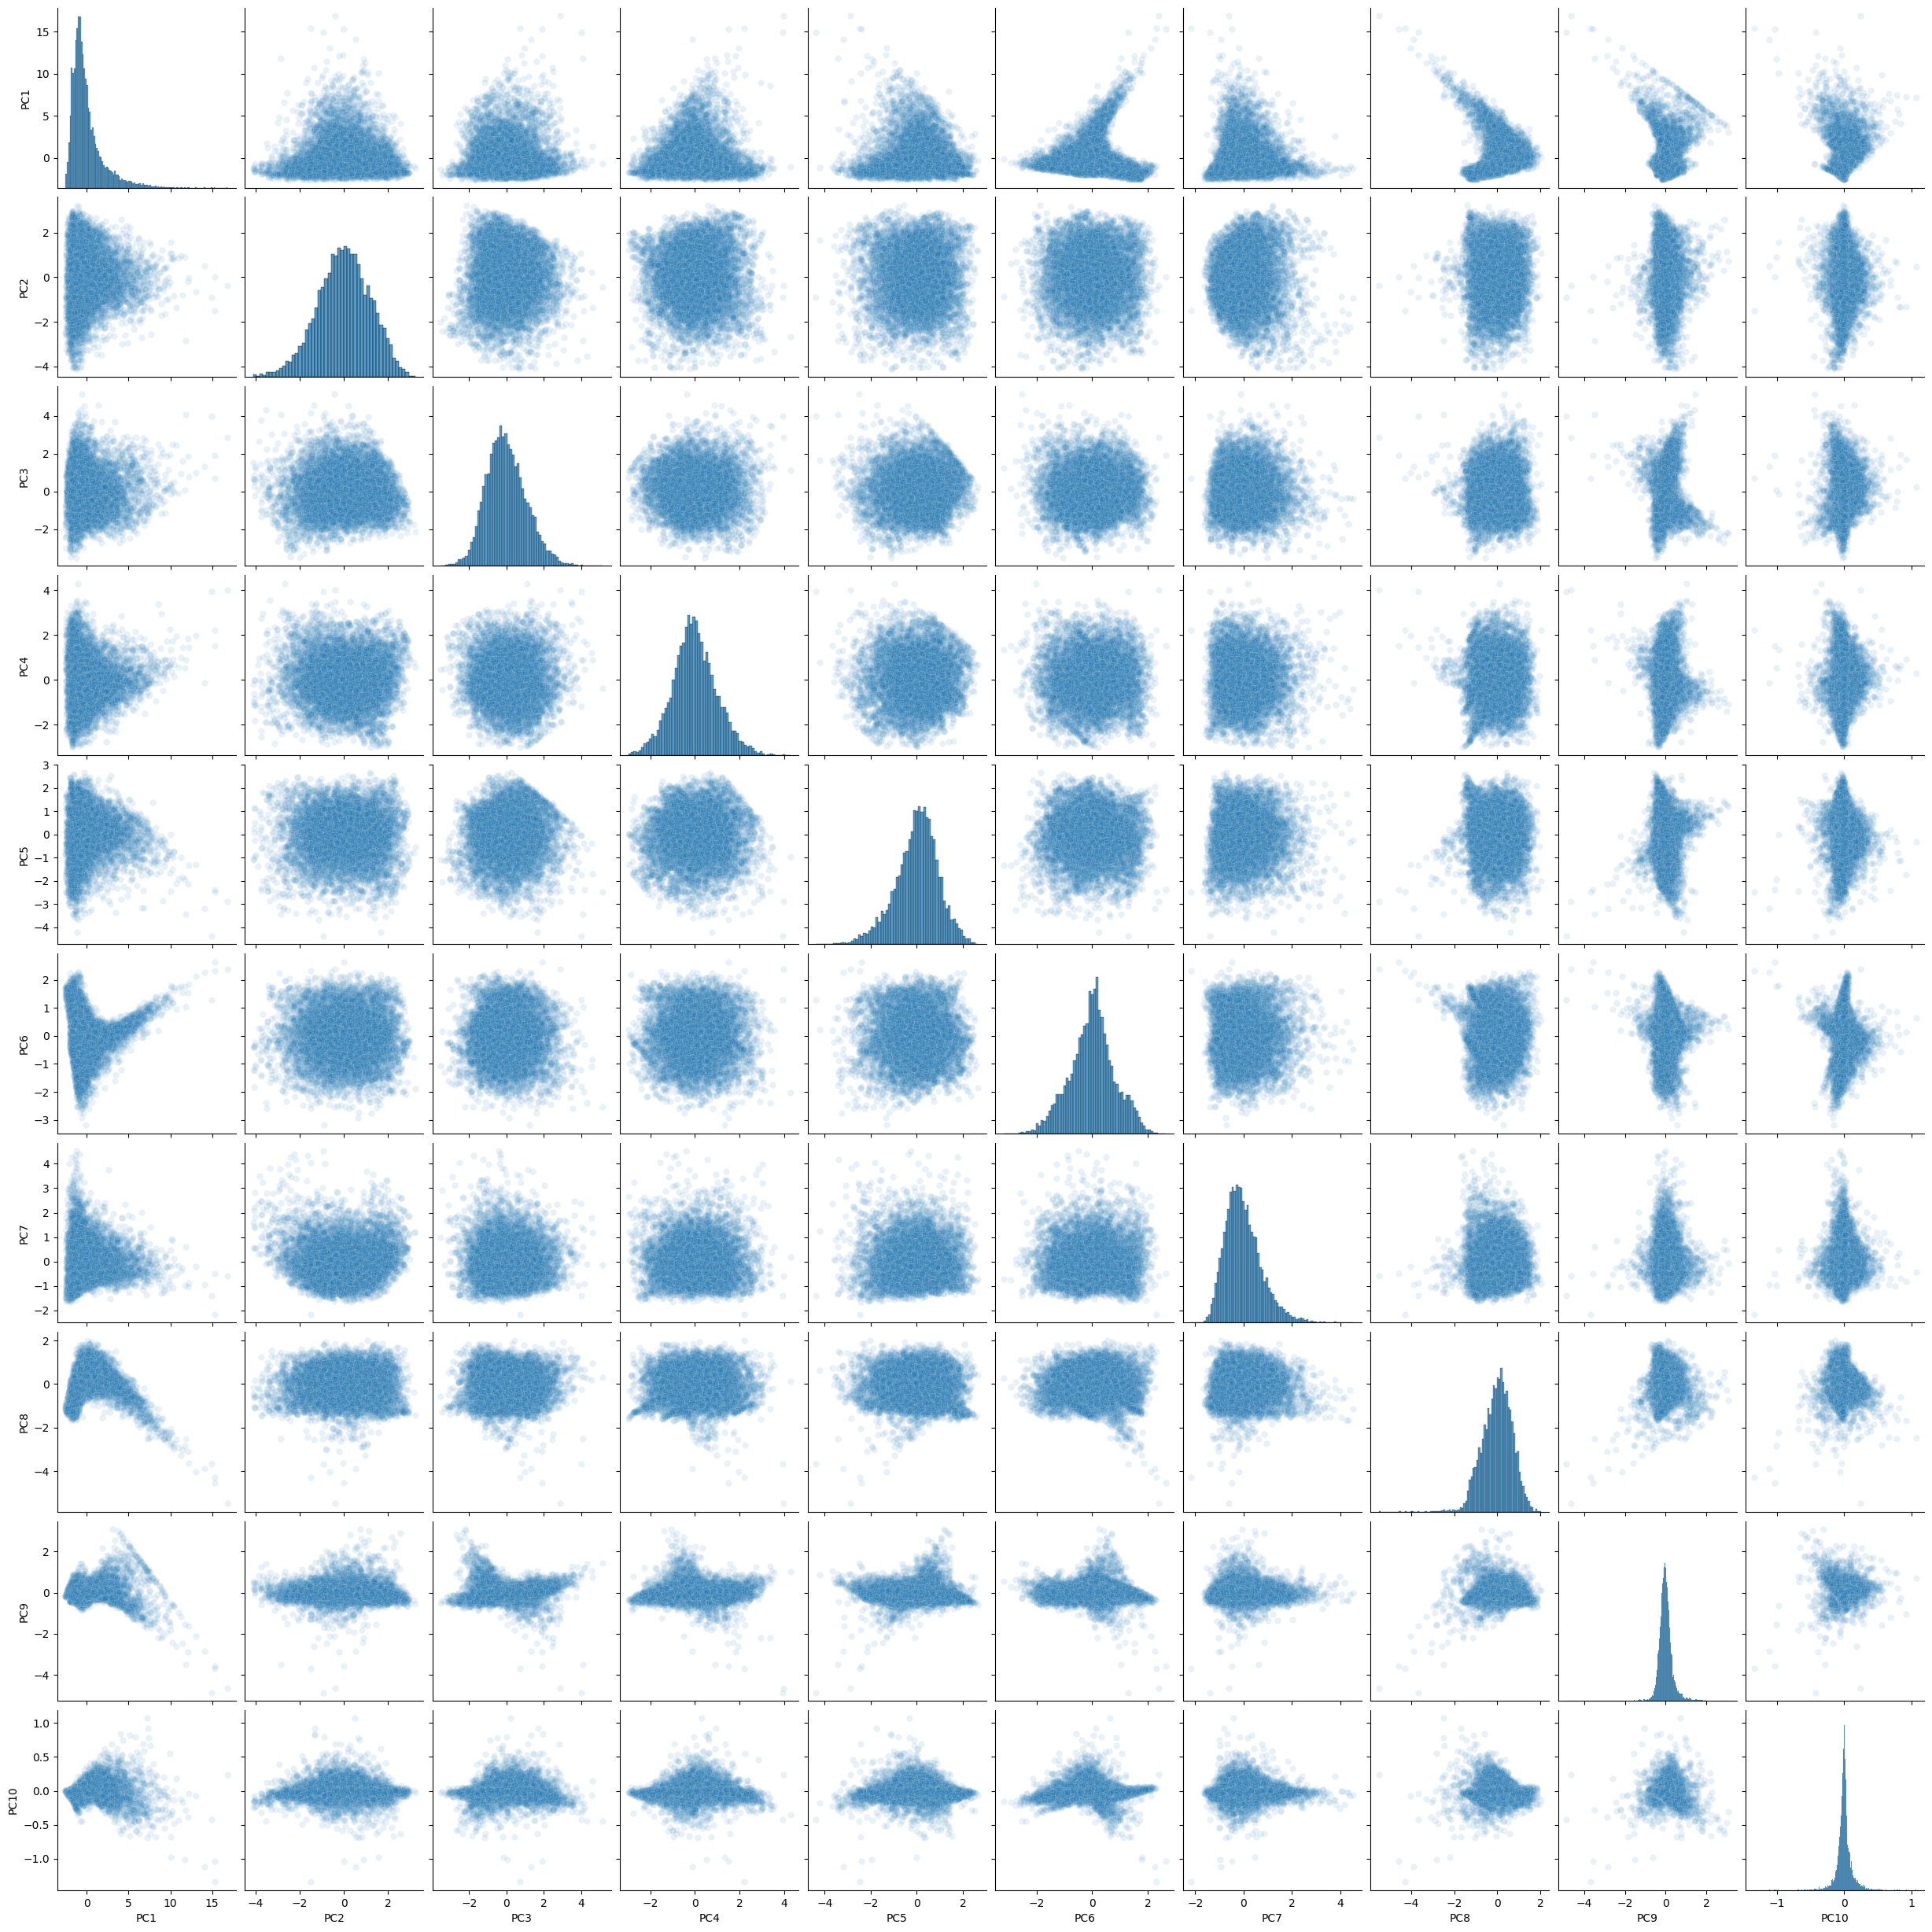

In [43]:
pca = PCA(n_components=10)
X_reduced_pca = pca.fit_transform(X_sample)

X_reduced_pca_df = pd.DataFrame(X_reduced_pca[:,:10])
X_reduced_pca_df.columns = [f"PC{col+1}" for col in X_reduced_pca_df.columns.tolist()]

sns.pairplot(X_reduced_pca_df, plot_kws={'alpha':0.1})

### Explained variance ratio



2025-11-26 11:36:11,968 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.

2025-11-26 11:36:11,972 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



<Axes: xlabel='principle_component', ylabel='explained_variance_ratio'>

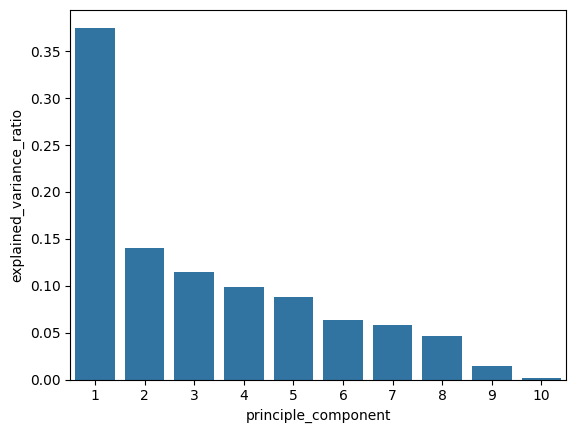

In [44]:

df_explained_variance_ratio = pd.DataFrame({'explained_variance_ratio': pca.explained_variance_ratio_,
              'principle_component': pd.Categorical([i+1 for i in range(len(pca.explained_variance_ratio_))])})

sns.barplot(data=df_explained_variance_ratio, y='explained_variance_ratio', x='principle_component')

## t-SNE


100%|██████████| 7/7 [03:43<00:00, 31.98s/it]


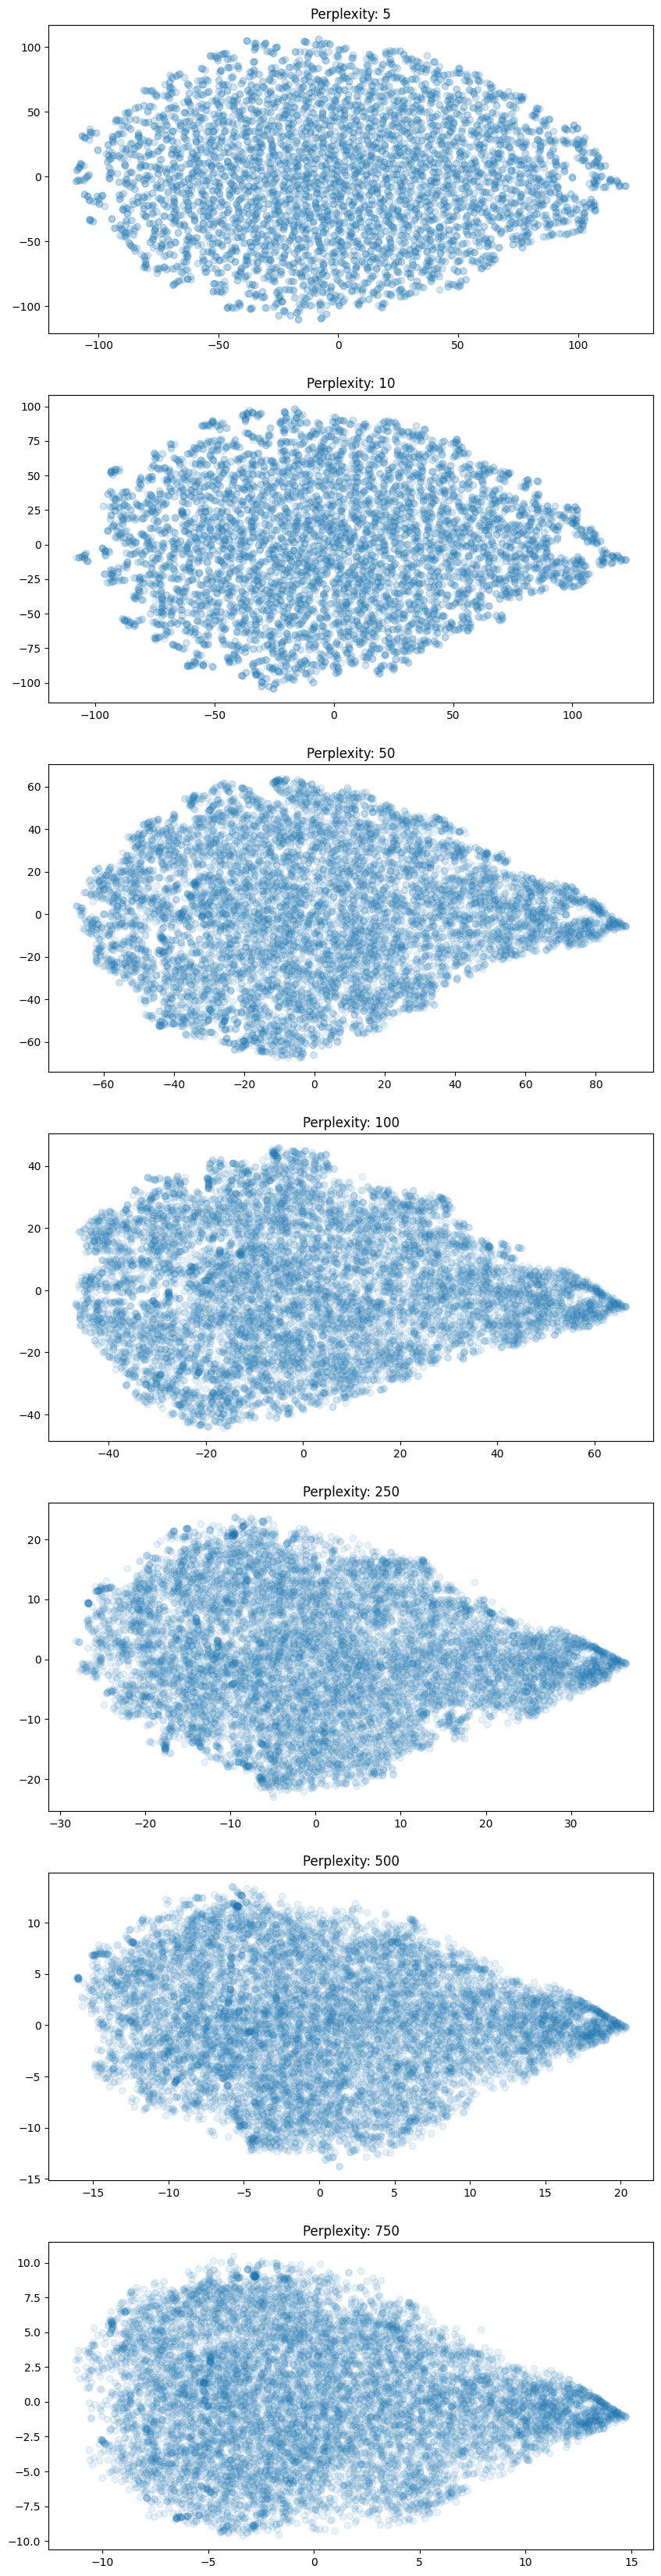

In [45]:
perplexities = [5, 10, 50, 100, 250, 500, 750]
fig, axs = plt.subplots(nrows=len(perplexities),figsize=(10, len(perplexities)*6))

for i, perplexity in enumerate(tqdm(perplexities)):
    tsne = TSNE(n_components = 2, perplexity=perplexity, n_jobs=-1)
    X_reduced_tsne = tsne.fit_transform(X_sample)

    axs[i].scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], alpha=0.1)
    axs[i].set_title(f"Perplexity: {perplexity}")

## UMAP

  0%|          | 0/5 [00:00<?, ?it/s]/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
 20%|██        | 1/5 [00:30<02:01, 30.36s/it]/Users/krusand/Documents/GitHub/02807-CT-Project/.venv/lib/python3.10/site-pac

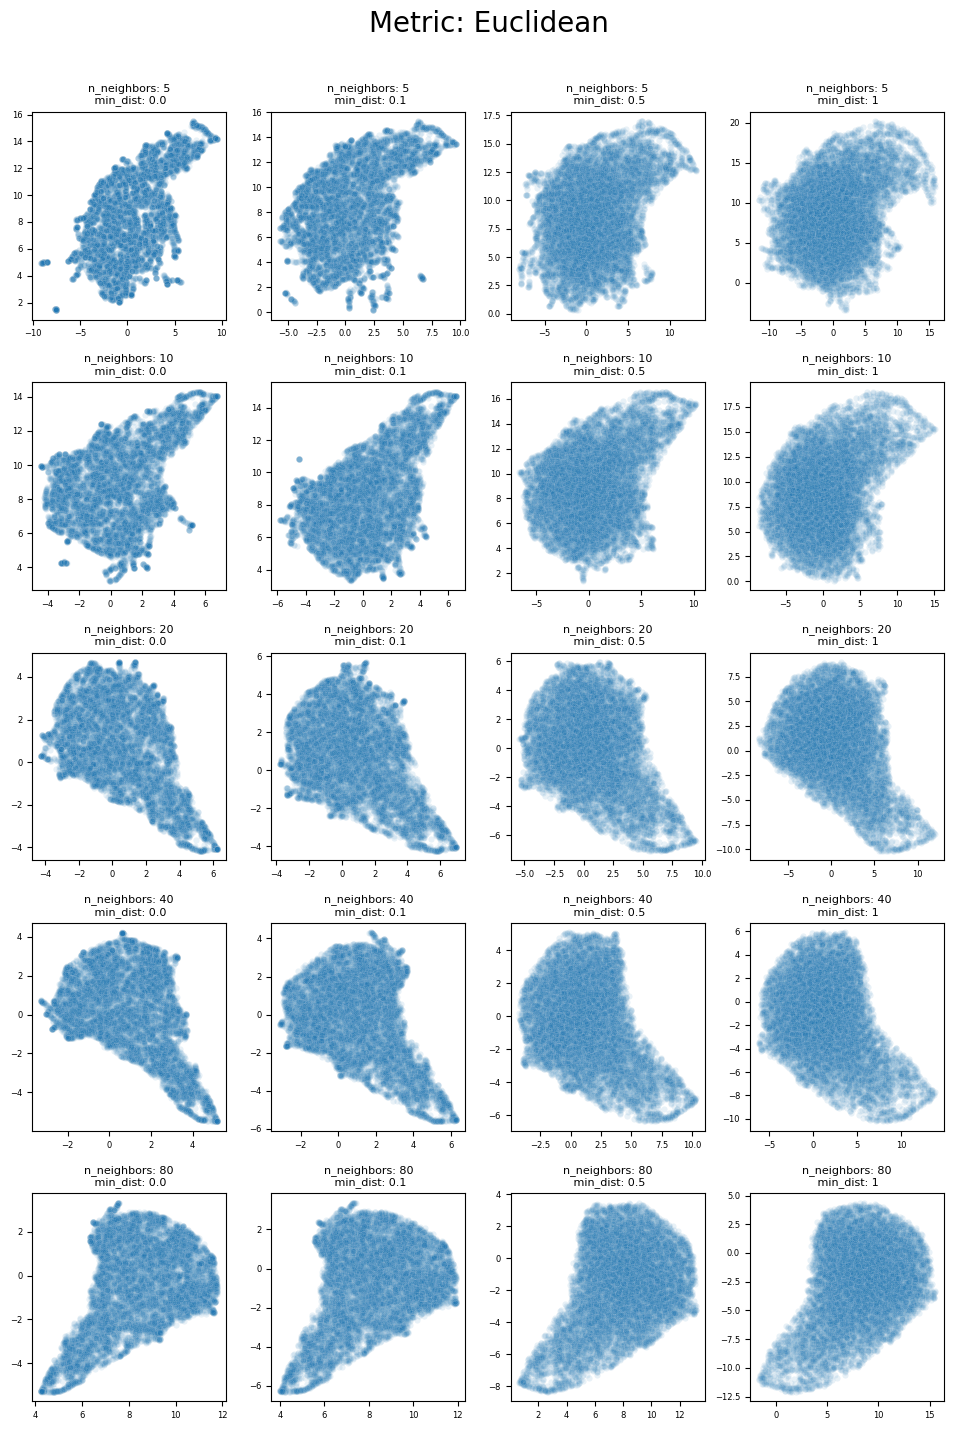

In [46]:
params = {
        "n_neighbors" : [5, 10, 20, 40, 80],
        "min_dist" : [0.0, 0.1, 0.5, 1],
        "metric" : ["euclidean", "manhattan"]
}

fig, axs = plt.subplots(nrows=len(params["n_neighbors"]), ncols=len(params["min_dist"]), figsize=(10,15))

for i in tqdm(range(len(params["n_neighbors"]))):
    for j in range(len(params["min_dist"])):
        n_neighbors = params["n_neighbors"][i]
        min_dist = params["min_dist"][j]
        metric = params["metric"][0]
        
        umap_model = UMAP(
            n_neighbors=n_neighbors,         # smaller = more local focus, higher = more global
            min_dist=min_dist,           # smaller = tighter clusters, higher = more spread
            n_components=2, 
            metric=metric,   
            random_state=42
        )
        
        X_reduced_umap = umap_model.fit_transform(X_sample)

        sns.scatterplot(x=X_reduced_umap[:, 0], y=X_reduced_umap[:, 1], s=20, alpha=0.1, ax=axs[i][j], legend=False)
        
        # Layout
        axs[i][j].set_title(f"n_neighbors: {n_neighbors}\n min_dist: {min_dist}", fontsize=8) # Set title
        axs[i][j].tick_params(axis='both', labelsize=6) # Reduce tick label font size

fig.suptitle(f"Metric: {metric.title()}", fontsize = 20)

plt.subplots_adjust(hspace=1.2)  # Increase vertical space
plt.tight_layout(rect=[0, 0.03, 0.97, 0.97])  # Leaves space for suptitle



## Clustering


### Agglomerative

Text(0.5, 1.0, 'Metric: euclidean, Linkage: ward')

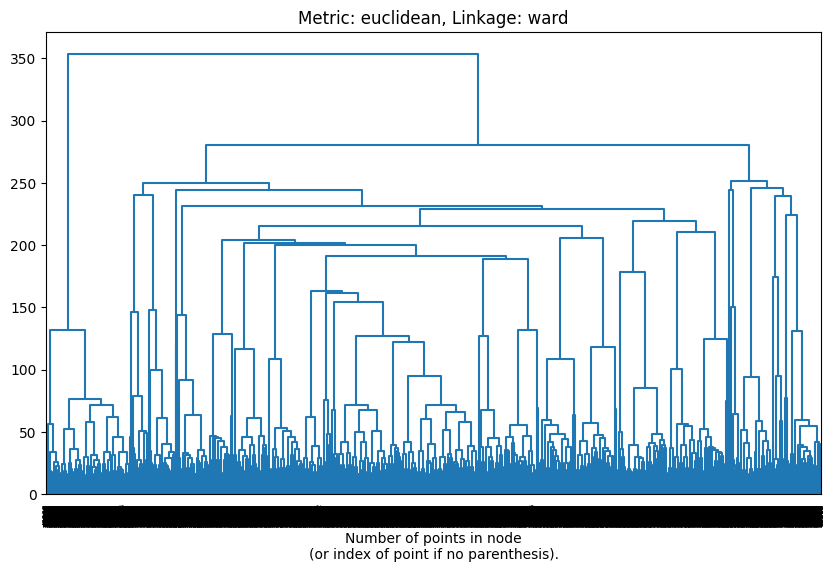

In [ ]:

def plot_dendrogram(model, **kwargs):
    "Taken from the sklearn documentation"
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# Plot euclidean + ward

metric = 'euclidean'
linkage = 'ward'
fig, ax = plt.subplots(ncols=1, figsize=(10,6))

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None,  linkage=linkage, metric=metric)

model = model.fit(X_sample)
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode = 'level', p=100, color_threshold=0,ax= ax)

ax.set_xlabel("Number of points in node\n(or index of point if no parenthesis).")
ax.set_title(f"Metric: {metric}, Linkage: {linkage}")


In [ ]:
from sklearn.base import BaseEstimator, ClusterMixin

class DBSCAN_own(ClusterMixin, BaseEstimator):
    def __init__(self, eps=1, m=1):
        self.eps = eps
        self.m = m
    
    def fit(self, X):
        def p_is_core(p):
            
            return False
        
        visited = [False] * X.shape[0]
        for i, p in enumerate(X):
            if visited[i] == False:
                core_point_bool = p_is_core(p)
                if not core_point_bool:
                    continue
                elif core_point_bool:
                    continue


### Kmeans
#### Testing Kmeans agreement:

In [ ]:
cluster_ids = []
n_comparisons = 50
for i in tqdm(range(n_comparisons)):

    km = KMeans(n_clusters=10)
    kmeans_cluster_pred = km.fit_predict(X_sample[feature_columns])
    cluster_ids.append(kmeans_cluster_pred)



cluster_ids_rand_matrix = []


for i in tqdm(range(n_comparisons)):
    cluster_ids_rand_matrix.append([])
    for j in range(n_comparisons):
        rand_score_ij = rand_score(cluster_ids[i], cluster_ids[j])
        cluster_ids_rand_matrix[i].append(rand_score_ij)




<Axes: >

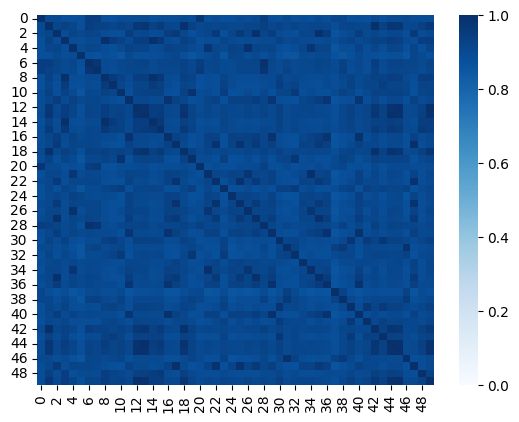

In [140]:
sns.heatmap(pd.DataFrame(cluster_ids_rand_matrix), cmap = 'Blues', vmin=0, vmax=1)


# Features based on rating matrix


In [29]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import rand_score, jaccard_score

from scipy.cluster.hierarchy import dendrogram

from umap import UMAP

import pandas as pd
import numpy as np

from config import *
from pandas.api.types import CategoricalDtype
import scipy.sparse as sparse

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from tqdm import tqdm

from functools import reduce

from utils import HourOfDayEncoder, DOWEncoder

def convert_to_user_term_matrix(ratings):
    """Converts from long to wide in CSR format. Input must have column names ['user', 'item', 'rating']"""
    users = ratings["user"].unique()
    item = ratings["item"].unique()
    shape = (len(users), len(item))

    # Create indices for users and movies
    user_cat = CategoricalDtype(categories=sorted(users), ordered=True)
    product_cat = CategoricalDtype(categories=sorted(item), ordered=True)
    user_index = ratings["user"].astype(user_cat).cat.codes
    product_index = ratings["item"].astype(product_cat).cat.codes

    # Conversion via COO matrix
    coo = sparse.coo_matrix((ratings["rating"], (user_index, product_index)), shape=shape)
    ratings_matrix = coo.tocsr()
    return user_index, product_index, ratings_matrix

In [30]:
ratings_long = pd.read_parquet(DATA_PREPROCESSED_DIR / "train_ratings_w_freq-0.33_w_rec-0.33_w_tfidf-0.33.pq")


user_index, _, ratings_matrix = convert_to_user_term_matrix(ratings_long)

In [4]:
svd = TruncatedSVD(n_components=50)
X_svd = svd.fit_transform(ratings_matrix)


In [74]:
pca = PCA(n_components=100)
X_pca = pca.fit_transform(ratings_matrix)

In [55]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

db_scores = {i: {
    'cluster_sizes': [],
    'db_scores': []
} for i in range(2,50)}

for i in tqdm(range(25)):
    for j in range(2,50):
        km = KMeans(n_clusters = j)
        y_pred_svd = km.fit_predict(X_svd)

        db_scores[j]["db_scores"].append(davies_bouldin_score(X_svd, y_pred_svd))
        db_scores[j]["cluster_sizes"].append(np.unique(y_pred_svd, return_counts=True)[1].tolist())



100%|██████████| 25/25 [18:33<00:00, 44.55s/it]


In [62]:
n_clusters = []
db_scores_list = []

for key, values in db_scores.items():
    n_clusters.extend([key]*len(values["db_scores"]))
    db_scores_list.extend(values["db_scores"])

db_scores_df = pd.DataFrame({'n_clusters': n_clusters,
              'db_score': db_scores_list})

2025-11-27 21:35:45,719 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.

2025-11-27 21:35:45,724 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



<Axes: xlabel='n_clusters', ylabel='db_score'>

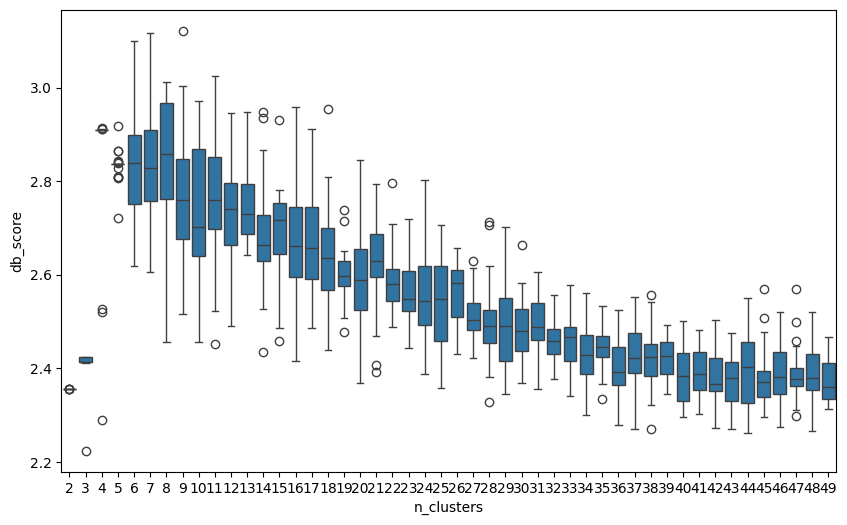

In [ ]:

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=db_scores_df, x='n_clusters', y='db_score')



In [127]:
cluster_id_list = []
cluster_sizes_iteration = []
cluster_sizes_list = []

for key, values in db_scores.items():
    for i, value_list in enumerate(values["cluster_sizes"]):
        cluster_id_list.append(key)
        cluster_sizes_iteration.append(i)
        cluster_sizes_list.append(min(value_list))


min_cluster_sizes_df = pd.DataFrame({
    'cluster': cluster_id_list,
    'iteration': cluster_sizes_iteration,
    'min_size': cluster_sizes_list
})

2025-11-27 21:39:59,377 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.

2025-11-27 21:39:59,381 - INFO - category.update:223 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



<Axes: xlabel='cluster', ylabel='min_size'>

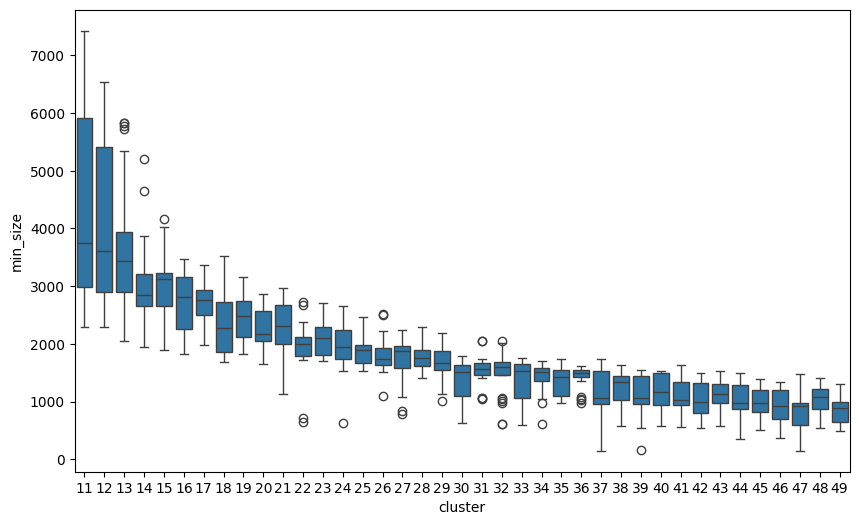

In [129]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=min_cluster_sizes_df[min_cluster_sizes_df["cluster"] > 10], x='cluster', y='min_size')


In [ ]:
km = KMeans(n_clusters=50)

y_pred_svd = km.fit_predict(X_svd)
y_pred_svd

In [79]:

umap = UMAP(n_neighbors=100, min_dist=0.5)
X_umap_svd = umap.fit_transform(X_svd)



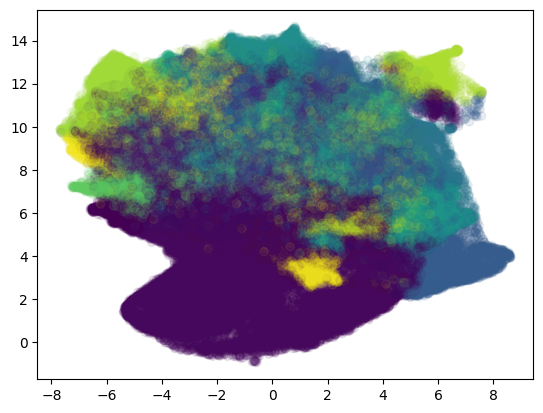

In [80]:
plt.scatter(X_umap_svd[:,0], X_umap_svd[:,1], c=y_pred_svd, alpha=0.1)

In [75]:
km = KMeans(n_clusters=50)
y_pred_pca = km.fit_predict(X_pca)

umap = UMAP(n_neighbors=10, min_dist=0.5)
X_umap_pca = umap.fit_transform(X_pca)


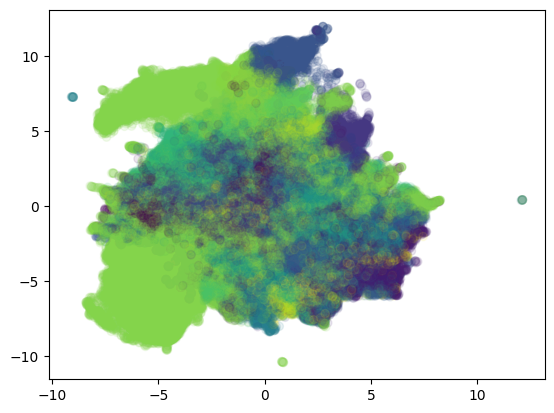

In [76]:
plt.scatter(X_umap_pca[:,0], X_umap_pca[:,1], c=y_pred_pca, alpha=0.1)

Agreement checking

100%|██████████| 50/50 [01:02<00:00,  1.26s/it]


<Axes: >

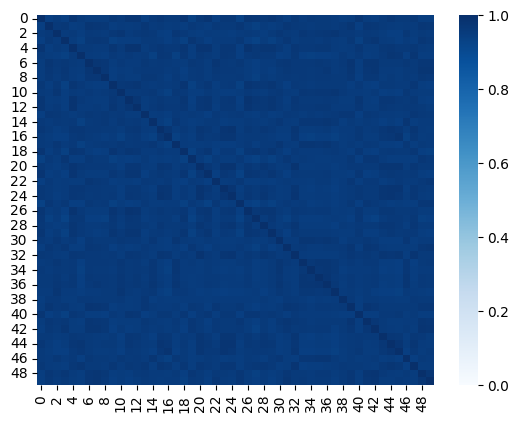

In [8]:


cluster_ids = []
n_comparisons = 50
for i in tqdm(range(n_comparisons)):

    km = KMeans(n_clusters=50)
    kmeans_cluster_pred = km.fit_predict(X_svd)
    cluster_ids.append(kmeans_cluster_pred)



cluster_ids_rand_matrix = []


for i in tqdm(range(n_comparisons)):
    cluster_ids_rand_matrix.append([])
    for j in range(n_comparisons):
        rand_score_ij = rand_score(cluster_ids[i], cluster_ids[j])
        cluster_ids_rand_matrix[i].append(rand_score_ij)

sns.heatmap(pd.DataFrame(cluster_ids_rand_matrix), cmap = 'Blues', vmin=0, vmax=1)



## Generate clusters for users

In [32]:
svd = TruncatedSVD(n_components=50)
X_svd = svd.fit_transform(ratings_matrix)

km = KMeans(n_clusters=50)
y_pred = km.fit_predict(X_svd)

ratings_long["user"].drop_duplicates()

0                1
15               2
111              3
144              4
156              5
             ...  
12084397    206205
12084420    206206
12084568    206207
12084653    206208
12084847    206209
Name: user, Length: 206209, dtype: int64

In [95]:
user_cluster_preds = (ratings_long[["user"]]
                .drop_duplicates()
                .assign(cluster=y_pred)
)

cluster_user_df = (user_cluster_preds
                   .groupby(["cluster"])
                    ["user"]
                    .unique()
                    .reset_index()
                    .assign(user = lambda x: x["user"].tolist()))

cluster_user_dict = {i: row["user"].tolist() for i,row in cluster_user_df.iterrows()}


In [ ]:
ratings_clusters = (ratings_long
 .merge(user_cluster_preds, on='user', how='left')
 .groupby(["cluster", "item"])
 .agg(rating = ('rating', 'mean'))
 .reset_index()
 )

In [ ]:
n_unique_products = ratings_long["item"].drop_duplicates().shape[0]


